# Is research-topic churn real or small-sample noise? (EXP16 demo)

This notebook is a runnable walkthrough of **`method.py`**, the final stage of experiment 16. The experiment asks whether the *home-only neighbourhood churn/novelty* signal is real. That signal is the finding that concepts whose early co-occurrence neighbourhood keeps changing (new partners, low edge persistence) later diffuse more broadly. The alternative is that the signal is a **thin-sample artefact**: with about 10 home papers per year, a concept's neighbourhood looks unstable simply because it was sampled sparsely.

The full pipeline (`s0_gate.py … s8_power.py`) ran on **13,444 selection concepts** from OpenAlex. It computed raw ego-network indicators and several noise-controlled variants:
* **V1**: fixed-n rarefaction (`*_rare5`, `*_rare10`)
* **V2**: within-concept year-permutation null, reported as excess over the null (`*_exc`), plus Chao-2005 Jaccard (`EP_chao`)
* **V3**: configuration / curveball nulls (`z_dens_cfg`, `z_pers_cfg`, `NOVCHURN_cfg`)
* **V4**: split-half reliability

Each variant was then related to the outcome `O2r_m50` (later broad diffusion) with partial Spearman correlations conditioned on the baseline covariates **B5** (`logvol`, `growth_c`, `offhome_share`, `entropy`, `reach`).

`method.py` itself does three things, all reproduced here:
1. Fit **OLS on the DEV body only**, using the B5 covariates standardised with the frozen EXP10 constants, with and without each churn variant. It then applies these models to every body and checks out-of-DEV Spearman with the outcome (`prediction_check.json`).
2. Build one `exp_gen_sol_out` example per concept (`input` = indicator values, `output` = `O2r_m50`, `predict_*` = model predictions).
3. Collect the headline verdict metadata (psp table, P1–P3, reliability, power, thin-sample share).

**Demo scale:** the demo uses a stratified **100-concept slice** of the full 7,748-concept analysis table: 34 DEV, and 22 each from OLDHO, COH1014 and COH1517. The expensive upstream stages (null models, bootstraps, cross-checks against dependency artifacts over 100 MB) are loaded as their precomputed full-run results. Code cells copy `method.py` as closely as possible.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (method.py uses it for logging)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This is the original import block of `method.py`. The `argparse`, `subprocess` and `lib/` path imports were only used for the CLI and the stage runner, so they are kept but not needed here. `common.jdump` / `setup_logger` come from the artifact's `lib/`, so the notebook defines two tiny stand-ins below. `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt

# --- notebook stand-ins for lib/common.py helpers (jdump, setup_logger) ---
RES = Path("demo_results"); RES.mkdir(exist_ok=True)
def jdump(obj, path):
    Path(path).write_text(json.dumps(obj, indent=1, default=lambda o: None if isinstance(o, float) and not math.isfinite(o) else str(o)))
def setup_logger(name):
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    return logger

## Data loading
`mini_demo_data.json` is fetched from the GitHub repository. If that fails, the notebook falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-5/experiment-16/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts in demo slice:", len(data["concepts"]), "| full-run examples:", data["full_run_n_examples"])

EXP16 thin-sample churn check: 100-concept stratified slice of the POOLED analysis table (34 DEV + 22 each OLDHO/COH1014/COH1517, finite O2r_m50 and B5) plus the small full-run summary results that method.py build_outputs() reads.
concepts in demo slice: 100 | full-run examples: 7748


## Configuration
This cell holds the model/column constants from `method.py` and the few tunable knobs.
* `MAX_CONCEPTS`: how many concepts of the demo slice to use. The demo uses all 100; the full run used 7,748 with finite `O2r_m50`.
* `MIN_BODY_N`: the minimum per-body sample size before a Spearman is reported. The original is `ok.sum() > 20`.
* `EVAL_BODIES`: the held-out bodies that the DEV-fitted models are applied to.

`method.py` has no iterations or bootstraps of its own. The B = 2000 bootstraps and 200 null draws belong to the upstream stages, whose results are loaded precomputed.

In [5]:
MAX_CONCEPTS = 100            # demo slice size (full run: 7748 concepts with finite O2r_m50)
MIN_BODY_N = 20               # original: Spearman reported only if ok.sum() > 20
EVAL_BODIES = ("OLDHO", "COH1014", "COH1517")

B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
PRED_X = {"B5": None, "B5_plus_NOVCHURN_raw": "NOVCHURN_raw", "B5_plus_NOVCHURN_exc": "NOVCHURN_exc",
          "B5_plus_NOVCHURN_cfg": "NOVCHURN_cfg", "B5_plus_OPEN_home": "OPEN_home",
          "B5_plus_OPEN_home_clean": "OPEN_home_clean"}
INPUT_COLS = ["NOV_res__raw", "edge_persistence__raw", "ego_density_W3__raw", "new_edge_rate__raw", "n_comm_W3__raw",
              "participation__raw", "NOVCHURN_raw", "OPEN_home", "NOV_res_rare10", "edge_persistence_rare10",
              "NOVCHURN_rare10", "NOV_res_rare5", "edge_persistence_rare5", "NOVCHURN_rare5", "NOV_res_exc",
              "edge_persistence_exc", "edge_persistence_nullmean", "NOVCHURN_exc", "EP_chao", "NOVCHURN_chao",
              "z_dens_cfg", "z_dens_k", "z_pers_cfg", "excess_pers_cfg", "NOVCHURN_cfg", "OPEN_home_clean",
              "OPEN_home_exc"]

## Upstream stages (not re-run here)
In the original, `run_stages()` runs 14 scripts in order: the gate, the fast engine, the seal, variants, nulls, composites, reliability, size, association, verdict, power and rederive. Each one is skipped if its output exists. These stages need the OpenAlex-derived ego networks from earlier artifacts and take about 30 minutes on 4 CPUs, so this demo does **not** call `run_stages`. The function is kept for reference.

In [6]:
STAGES = [("s0_gate.py", "gate_t0.json"), ("tests/u_fast6.py", "unit_tests_fast6.json"),
          ("s1_freeze.py", "frozen_spec.json"), ("s2_variants.py", "s2_scalars_full.parquet"),
          ("s3_nulls.py", "v3_nulls_full.parquet"), ("tests/u_nulls.py", "unit_tests_nulls.json"),
          ("tests/planted.py", "planted_checks.json"), ("s4_composites.py", "clean_variants.parquet"),
          ("s4b_outcome_rel.py", "reliability.json"), ("s5_size.py", "size_dependence.json"),
          ("s6_assoc.py", "clean_vs_raw_psp_cells.json"), ("s7_verdict.py", "clean_vs_raw_psp.json"),
          ("s8_power.py", "power_frame_n.json"), ("rederive.py", "rederive.json")]


def run_stages(force: bool) -> None:   # original orchestrator (NOT called in the demo)
    for script, out in STAGES:
        out = RES / out
        if out.exists() and not force:
            logger.info(f"skip {script} ({out.name} exists)")
            continue
        if script == "s1_freeze.py" and out.exists():
            logger.warning("frozen_spec.json exists: never re-freeze (seal)")
            continue
        logger.info(f"running {script}")
        subprocess.run([sys.executable, script], check=True)

print("stages (precomputed in the full run):", [s for s, _ in STAGES])

stages (precomputed in the full run): ['s0_gate.py', 'tests/u_fast6.py', 's1_freeze.py', 's2_variants.py', 's3_nulls.py', 'tests/u_nulls.py', 'tests/planted.py', 's4_composites.py', 's4b_outcome_rel.py', 's5_size.py', 's6_assoc.py', 's7_verdict.py', 's8_power.py', 'rederive.py']


## Dependency cross-checks
`concept_key_check()` checks that every analysed concept id appears in the OpenAlex concept-recognition table of the dataset artifact art_O7Dq4L02QnDN, and that its level agrees. `exp12_crosscheck()` checks that the home-build component values match EXP12's `open_features.parquet`. Both read dependency files over 100 MB, so the notebook versions return the stored full-run results. The originals found 100% coverage, 100% level agreement, and component values identical to 1e-9.

In [7]:
def concept_key_check() -> dict:
    """Dependency art_O7Dq4L02QnDN is used ONLY as the concept key: coverage of the analysed concept_ids in its
    concept_recognition table and agreement of the OpenAlex level. (Demo: precomputed full-run result.)"""
    return data["precomputed_crosschecks"]["concept_key_check"]


def exp12_crosscheck() -> dict:
    """EXP12 (art_uw4OeagJP3rv) open_features.parquet: cross-check of the home-build component values where it
    overlaps (EXP5 frame). (Demo: precomputed full-run result.)"""
    return data["precomputed_crosschecks"]["exp12_home_crosscheck"]

print(json.dumps(concept_key_check(), indent=1))

{
 "dependency": "art_O7Dq4L02QnDN concept_recognition (concept key only; no O5 outcome used)",
 "n_recognition_rows": 65026,
 "n_analysed": 13444,
 "n_found": 13444,
 "coverage_by_body": {
  "COH1014": 1.0,
  "COH1517": 1.0,
  "DEV": 1.0,
  "OLDHO": 1.0
 },
 "level_agreement": 1.0
}


## Load the analysis table and the stage results
In `build_outputs()`, the first lines read the frozen spec, which holds the EXP10 B5 standardisation constants `mu`/`sd`. They also read the verdict file (`clean_vs_raw_psp.json`), the reliability, power and size-dependence results, and the POOLED analysis table from `tables.load_tables()`. The table has one row per concept, with its body, the B5 covariates, all raw and clean churn variants, and the outcome `O2r_m50`. Here all of these come from `data`.

In [8]:
spec = data["frozen_spec"]
pm = spec["exp10_prediction_models"]["B5"]
V = data["clean_vs_raw_psp"]
rel = data["reliability"]
pw = data["power_frame_n"]
sz = data["size_dependence"]
T = pd.DataFrame(data["concepts"]).head(MAX_CONCEPTS)                 # was: load_tables()["POOLED"]
T = T.apply(lambda s: pd.to_numeric(s) if s.name in B5 + INPUT_COLS + ["O2r_m50", "O2r_resid"] else s)
T[B5 + INPUT_COLS + ["O2r_m50", "O2r_resid"]] = T[B5 + INPUT_COLS + ["O2r_m50", "O2r_resid"]].astype(float)
T = T[np.isfinite(T.O2r_m50)].reset_index(drop=True)
print(T.body.value_counts().to_dict())
T[["concept_id", "name", "body", "n_home_early", "NOVCHURN_raw", "NOVCHURN_exc", "OPEN_home", "O2r_m50"]].head(8)

{'DEV': 34, 'OLDHO': 22, 'COH1014': 22, 'COH1517': 22}


,concept_id,name,body,n_home_early,NOVCHURN_raw,NOVCHURN_exc,OPEN_home,O2r_m50
0,2776251621,Acetonide,DEV,283,-1.226929,-0.177911,0.506227,3.898838
1,2778510232,High resolution manometry,DEV,96,-1.271196,-0.195173,-0.483403,3.032037
2,2776433454,Rimonabant,DEV,114,-0.116658,0.214435,1.073949,5.765610
3,2780434240,Urban rail transit,DEV,85,-0.669253,-0.301602,0.131595,4.176321
4,2909437798,Transversus abdominis,DEV,87,-1.193110,-0.071765,-0.076096,2.153846
5,184150571,SGK1,DEV,61,-0.953710,-0.452416,-0.459325,4.542373
6,2993319417,Coal fired,DEV,68,-0.064206,-0.145370,0.701339,4.923940
7,2910678782,Postpartum haemorrhage,DEV,62,-0.377455,-0.609153,0.112368,2.916686


## DEV-only OLS prediction models
The B5 covariates are standardised with the **frozen** EXP10 `mu`/`sd`, so nothing is re-estimated on the evaluation data. For each model in `PRED_X`, an OLS is fitted on **DEV concepts only**, either B5 alone or B5 plus one churn variant. A missing variant value is imputed with the DEV median, and the imputation is flagged. The coefficients are then applied to every concept.

In [9]:
Zb = np.column_stack([(T[c].to_numpy(float) - pm["mu"][c]) / pm["sd"][c] for c in B5])
dev = (T.body == "DEV").to_numpy() & np.all(np.isfinite(Zb), 1)
y = T.O2r_m50.to_numpy(float)
preds, imputed, coefs = {}, {}, {}
for nm, x in PRED_X.items():
    X = Zb.copy()
    if x is not None:
        v = T[x].to_numpy(float)
        med = float(np.nanmedian(v[dev]))
        imputed[nm] = ~np.isfinite(v)
        v = np.where(np.isfinite(v), v, med)
        X = np.c_[X, v]
    A = np.c_[np.ones(len(T)), X]
    okf = dev & np.all(np.isfinite(A), 1)
    b = np.linalg.lstsq(A[okf], y[okf], rcond=None)[0]
    coefs[nm] = b.tolist()
    preds[nm] = A @ b
print("DEV concepts used for the fit:", int(dev.sum()))
pd.DataFrame({nm: np.round(c, 4) for nm, c in coefs.items()}.items(), columns=["model", "coef (intercept, B5..., variant)"])

DEV concepts used for the fit: 34


,model,"coef (intercept, B5..., variant)"
0,B5,"[4.5946, -0.0869, 0.1978, -0.0605, 0.5595, 0.8..."
1,B5_plus_NOVCHURN_raw,"[4.6301, 0.0684, 0.1818, -0.2364, 0.8781, 0.53..."
2,B5_plus_NOVCHURN_exc,"[4.5916, -0.0361, 0.2381, -0.1295, 0.7096, 0.6..."
3,B5_plus_NOVCHURN_cfg,"[4.6015, 0.0048, 0.1878, -0.1205, 0.6688, 0.69..."
4,B5_plus_OPEN_home,"[4.5745, -0.0728, 0.1642, -0.0856, 0.6454, 0.7..."
5,B5_plus_OPEN_home_clean,"[4.5657, -0.0459, 0.1622, -0.0889, 0.6485, 0.7..."


## Out-of-DEV check (`prediction_check.json`)
For each held-out body, compute the Spearman correlation between every model's prediction and the outcome, and the **gain over B5**. In the full run this gain is about 0. The churn variants add little *predictive* signal beyond the B5 baseline, even though some of them have non-zero partial correlations.

In [10]:
chk = {"note": "OLS fitted on DEV only; out-of-DEV Spearman with O2r_m50 (gain over B5 expected ~0)", "coef": coefs}
for body in EVAL_BODIES:
    m = (T.body == body).to_numpy()
    ent = {}
    for nm, p in preds.items():
        ok = m & np.isfinite(p)
        ent[nm] = float(stats.spearmanr(p[ok], y[ok])[0]) if ok.sum() > MIN_BODY_N else None
    ent["n"] = int(m.sum())
    ent["gain_vs_B5"] = {nm: (ent[nm] - ent["B5"]) if ent[nm] is not None and ent["B5"] is not None else None
                         for nm in PRED_X if nm != "B5"}
    chk[body] = ent
jdump(chk, RES / "prediction_check.json")
pd.DataFrame({b: {nm: chk[b][nm] for nm in PRED_X} for b in EVAL_BODIES}).round(3)

,OLDHO,COH1014,COH1517
B5,0.616,0.632,0.329
B5_plus_NOVCHURN_raw,0.650,0.680,0.362
B5_plus_NOVCHURN_exc,0.530,0.557,0.298
B5_plus_NOVCHURN_cfg,0.615,0.658,0.327
B5_plus_OPEN_home,0.612,0.626,0.268
B5_plus_OPEN_home_clean,0.635,0.652,0.282


## Build `method_out.json` (`exp_gen_sol_out` format)
This step writes one example per concept: `input` is a JSON string with the concept id, body, `t0`, `n_home_early` and all 27 indicator variants; `output` is `O2r_m50`; each `predict_*` field holds a model prediction. Metadata records the body, the analysis group, the residualised outcome, and which clean variants are missing or imputed.

In [11]:
exs = []
for i, r in T.iterrows():
    inp = {"concept_id": str(r.concept_id), "name": str(r["name"]), "body": r.body, "t0": int(r.t0),
           "n_home_early": int(r.n_home_early)}
    for c in INPUT_COLS:
        v = r[c]
        inp[c] = None if not np.isfinite(v) else round(float(v), 6)
    e = {"input": json.dumps(inp), "output": f"{r.O2r_m50:.6f}"}
    for nm, p in preds.items():
        e[f"predict_{nm}"] = f"{p[i]:.6f}" if np.isfinite(p[i]) else "nan"
    e["metadata_body"] = r.body
    e["metadata_agroup"] = r.agroup
    e["metadata_O2r_resid"] = None if not np.isfinite(r.O2r_resid) else float(r.O2r_resid)
    e["metadata_imputed_variants"] = [nm for nm in imputed if imputed[nm][i]]
    e["metadata_missing_clean_variants"] = [c for c in ("NOVCHURN_exc", "NOVCHURN_rare10", "NOVCHURN_cfg",
                                                        "OPEN_home_clean") if not np.isfinite(r[c])]
    exs.append(e)
print(len(exs), "examples; first:")
print(json.dumps(exs[0], indent=1)[:900])

100 examples; first:
{
 "input": "{\"concept_id\": \"2776251621\", \"name\": \"Acetonide\", \"body\": \"DEV\", \"t0\": 2003, \"n_home_early\": 283, \"NOV_res__raw\": -0.748178, \"edge_persistence__raw\": 0.422078, \"ego_density_W3__raw\": 0.787879, \"new_edge_rate__raw\": 0.866667, \"n_comm_W3__raw\": 4.0, \"participation__raw\": 0.507324, \"NOVCHURN_raw\": -1.226929, \"OPEN_home\": 0.506227, \"NOV_res_rare10\": -0.882794, \"edge_persistence_rare10\": 0.174167, \"NOVCHURN_rare10\": -0.767041, \"NOV_res_rare5\": null, \"edge_persistence_rare5\": 0.074324, \"NOVCHURN_rare5\": null, \"NOV_res_exc\": -0.095007, \"edge_persistence_exc\": -0.014901, \"edge_persistence_nullmean\": 0.436979, \"NOVCHURN_exc\": -0.177911, \"EP_chao\": 0.738814, \"NOVCHURN_chao\": -1.022465, \"z_dens_cfg\": 34.037058, \"z_dens_k\": 29.39951, \"z_pers_cfg\": 82.281702, \"excess_pers_cfg\": 0.421052, \"NOVCHURN_cfg\": -1.686886, \"OPEN_h


## Verdict metadata
This step collects the full-run headline results: the mechanical verdict (`PARTLY_THIN`), predictions P1–P3, and the partial-Spearman (psp) table of each variant with `O2r_m50 | B5 + R2` per body. It also gathers the split-half reliabilities, the thin-sample share, and the power statement. Then it writes the demo's `method_out.json`.

In [12]:
vd = V["verdict"]
head = {h["variant"]: {b: h[b].get("psp") for b in ("DEV", "OLDHO", "COH1014", "COH1517", "POOLED")}
        for h in V["headline_R2_O2r_m50"]}
meta = {"method_name": "Thin-sample confound check of home-only neighbourhood churn (raw vs noise-controlled "
                       "variants)",
        "label": "selection data, outcomes previously unsealed: robustness evidence, not confirmation",
        "verdict": vd["verdict"], "DEGREE_ARTEFACT_PERSISTENCE": vd["DEGREE_ARTEFACT_PERSISTENCE"],
        "predictions_P1_P3": {k: v["holds"] for k, v in V["predictions"].items()},
        "P_detail": V["predictions"], "headline_psp_R2_O2r_m50": head,
        "reliability_pooled_SB": {k: v["pooled"]["SB"] for k, v in rel["variants"].items()},
        "outcome_reliability_SB": rel["outcome"]["O2r_m50"]["pooled"]["SB"],
        "thin_sample_share_R2": sz["thin_sample_share"]["POOLED"]["R2"],
        "power_plain_language": pw["plain_language"],
        "concept_key_check": concept_key_check(), "exp12_home_crosscheck": exp12_crosscheck(),
        "n_examples": len(exs), "prediction_models": "OLS on DEV (B5 standardised with EXP10 frozen mu/sd); "
                                                     "NaN variants imputed with the DEV median (flagged)"}
out = {"metadata": meta, "datasets": [{"dataset": "selection_concepts", "examples": exs}]}
Path("method_out.json").write_text(json.dumps(out, indent=1, default=lambda o: None if isinstance(o, float)
                                              and not math.isfinite(o) else str(o)))
setup_logger("method")
logger.info(f"method_out.json: {len(exs)} examples; verdict {vd['verdict']}")

11:46:22|INFO   |method_out.json: 100 examples; verdict PARTLY_THIN


## Results and visualisation
**Left panel:** the full-run pooled partial Spearman (with 95% bootstrap CI) of the raw churn composite and its noise-controlled variants. Most of the raw signal disappears under the V2 permutation-excess variant, and about 70% survives fixed-n rarefaction. **Middle panel:** in the demo slice, raw edge persistence and its V2 null mean against `log n_home_early`. The null mean follows the sample size, which is the thin-sample share. **Right panel:** out-of-DEV Spearman for each model on the demo slice. With only 22 concepts per body these values are noisy; the full-run values are in the artifact's `results/prediction_check.json`.

VERDICT: PARTLY_THIN | P1-P3: {'P1': False, 'P2': True, 'P3': True} | thin-sample share R2 = 0.66
Outcome reliability SB = 0.895

Full-run partial Spearman with O2r_m50 | B5+R2 (B=2000):
                   DEV  OLDHO  COH1014  COH1517  POOLED  SB_pooled
NOVCHURN_raw     0.116  0.113    0.113    0.161   0.116      0.476
NOVCHURN_rare5   0.127  0.140    0.149    0.105   0.130      0.359
NOVCHURN_rare10  0.066  0.044    0.076    0.176   0.078        NaN
NOVCHURN_chao    0.107  0.123    0.099    0.153   0.108        NaN
NOVCHURN_cfg     0.115  0.071    0.114    0.088   0.106      0.618
NOVCHURN_exc     0.008  0.006   -0.007    0.063   0.008      0.014
NOVCHURN_zperm   0.007  0.021   -0.003    0.073   0.012      0.023
OPEN_home        0.109  0.070    0.074    0.091   0.085      0.485
OPEN_home_clean  0.133  0.094    0.108    0.129   0.115      0.577
z_dens_cfg      -0.087 -0.089   -0.127   -0.047  -0.091      0.698
z_pers_cfg      -0.100 -0.122   -0.172   -0.066  -0.116      0.709


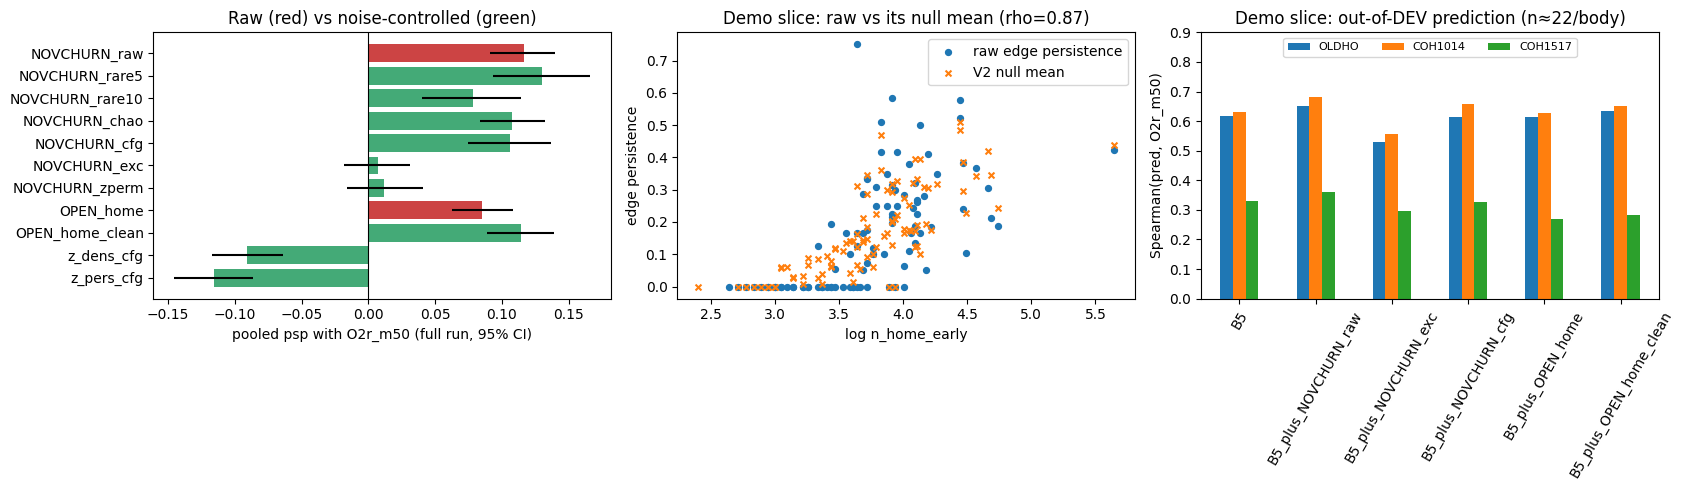

In [13]:
print(f"VERDICT: {meta['verdict']} | P1-P3: {meta['predictions_P1_P3']} | thin-sample share R2 = {meta['thin_sample_share_R2']:.2f}")
print(f"Outcome reliability SB = {meta['outcome_reliability_SB']:.3f}")
show = ["NOVCHURN_raw", "NOVCHURN_rare5", "NOVCHURN_rare10", "NOVCHURN_chao", "NOVCHURN_cfg", "NOVCHURN_exc",
        "NOVCHURN_zperm", "OPEN_home", "OPEN_home_clean", "z_dens_cfg", "z_pers_cfg"]
H = {h["variant"]: h for h in V["headline_R2_O2r_m50"]}
show = [s for s in show if s in H]
tab = pd.DataFrame({s: {**{b: H[s][b]["psp"] for b in ("DEV", "OLDHO", "COH1014", "COH1517", "POOLED")},
                        "SB_pooled": meta["reliability_pooled_SB"].get(s)} for s in show}).T
print("\nFull-run partial Spearman with O2r_m50 | B5+R2 (B=2000):")
print(tab.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ps = [H[s]["POOLED"]["psp"] for s in show]
lo = [H[s]["POOLED"]["psp"] - H[s]["POOLED"]["ci"][0] for s in show]
hi = [H[s]["POOLED"]["ci"][1] - H[s]["POOLED"]["psp"] for s in show]
ax[0].barh(show[::-1], ps[::-1], xerr=[lo[::-1], hi[::-1]], color=["#c44" if "raw" in s or s == "OPEN_home" else "#4a7" for s in show[::-1]])
ax[0].axvline(0, color="k", lw=0.8); ax[0].set_xlabel("pooled psp with O2r_m50 (full run, 95% CI)")
ax[0].set_title("Raw (red) vs noise-controlled (green)")

ln = np.log(T.n_home_early.astype(float))
ax[1].scatter(ln, T.edge_persistence__raw, s=18, label="raw edge persistence")
ax[1].scatter(ln, T.edge_persistence_nullmean, s=18, marker="x", label="V2 null mean")
ok = np.isfinite(T.edge_persistence__raw) & np.isfinite(T.edge_persistence_nullmean)
r_null = stats.spearmanr(T.edge_persistence__raw[ok], T.edge_persistence_nullmean[ok])[0]
ax[1].set_xlabel("log n_home_early"); ax[1].set_ylabel("edge persistence")
ax[1].set_title(f"Demo slice: raw vs its null mean (rho={r_null:.2f})"); ax[1].legend()

pc = pd.DataFrame({b: {nm: chk[b][nm] for nm in PRED_X} for b in EVAL_BODIES})
pc.plot.bar(ax=ax[2]); ax[2].set_ylim(top=max(0.9, float(np.nanmax(pc.to_numpy(float))) + 0.2)); ax[2].legend(ncol=3, loc="upper center", fontsize=8); ax[2].set_ylabel("Spearman(pred, O2r_m50)")
ax[2].set_title(f"Demo slice: out-of-DEV prediction (n≈{chk['OLDHO']['n']}/body)")
ax[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()